# RQ5 — Previous / Current / Next Context

## Research question

> Is true-gate information contained in the current movement itself, or can the neighbouring movements predict the same label?

RQ4 showed that repeated physical transitions can have stable acoustic fingerprints. RQ5 therefore tests a potential shortcut directly: if a model can identify the true digit from the movements immediately before and after it, then good classification does not necessarily imply that the current true-gate event has been isolated.

### Data

Two historical single-wheel datasets are used:

- `digit_W1_data.zip`
- `digit_W2_data.zip`

Each decision contains a continuous 10-movement cycle. The candidate movement is represented by three positions:

- **Previous** — movement immediately before the candidate
- **Current** — the candidate movement itself
- **Next** — movement immediately after the candidate

Because the scan closes the full 10-digit cycle, Previous and Next are defined circularly at the ends of the sequence.

### Ablations

Seven fixed representations are compared:

`Previous`, `Current`, `Next`, `Previous + Current`, `Current + Next`, `Previous + Next`, and `Full`.

`Previous + Next` is the key context-only condition because it deliberately removes the Current movement.

### Evaluation

A logistic model is evaluated with **leave-one-profile-out** validation. All candidates from the held-out profile stay together. The main comparison is profile-level true-digit rank between:

- `Previous + Next` and `Current`
- `Full` and `Current`

The purpose is not to build the best model. It is to determine where the predictive information is located.

## 1. Reconstruct the historical decisions

In [1]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import shutil
import zipfile
import json

import numpy as np
import pandas as pd
from IPython.display import display

MYDRIVE = Path("/content/drive/MyDrive")
HIST_ROOT = MYDRIVE / "dataset" / "raw" / "historical_data"
PROJECT_ROOT = MYDRIVE / "Padlock_Reproduction_v1"

results_candidates = [
    PROJECT_ROOT / "results",
    PROJECT_ROOT / "Padlock_Reproduction_v1" / "results",
]

RESULTS_ROOT = next(
    (
        p for p in results_candidates
        if p.exists()
    ),
    None,
)

if RESULTS_ROOT is None:
    raise FileNotFoundError(
        "Could not locate Padlock_Reproduction_v1/results."
    )

RESULT_DIR = (
    RESULTS_ROOT / "05_RQ5_Prev_Current_Next"
)

CACHE_DIR = (
    RESULTS_ROOT / "feature_cache"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CACHE_PATH = (
    CACHE_DIR
    / "RQ5_context_interpretable_v1.npz"
)

LOCAL_ROOT = Path(
    "/content/RQ5_context"
)

LOCAL_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

sources = {
    "W1": HIST_ROOT / "digit_W1_data.zip",
    "W2": HIST_ROOT / "digit_W2_data.zip",
}

dataset_dirs = {}

for label, drive_zip in sources.items():
    if not drive_zip.exists():
        raise FileNotFoundError(drive_zip)

    local_zip = (
        LOCAL_ROOT / drive_zip.name
    )

    extract_dir = (
        LOCAL_ROOT / drive_zip.stem
    )

    run_dirs = []

    if extract_dir.exists():
        run_dirs = sorted(
            [
                p
                for p in extract_dir.rglob("run_*")
                if p.is_dir()
            ],
            key=lambda p: int(
                p.name.split("_")[-1]
            ),
        )

    if not run_dirs:
        shutil.copy2(
            drive_zip,
            local_zip,
        )

        if extract_dir.exists():
            shutil.rmtree(
                extract_dir
            )

        extract_dir.mkdir(
            parents=True
        )

        with zipfile.ZipFile(
            local_zip,
            "r",
        ) as z:
            z.extractall(
                extract_dir
            )

        run_dirs = sorted(
            [
                p
                for p in extract_dir.rglob("run_*")
                if p.is_dir()
            ],
            key=lambda p: int(
                p.name.split("_")[-1]
            ),
        )

    dataset_dirs[label] = {
        "root": extract_dir,
        "runs": run_dirs,
    }

    print(
        label,
        "runs:",
        len(run_dirs),
    )

Mounted at /content/drive
W1 runs: 840
W2 runs: 960


In [2]:
rows = []

for dataset_label, info in dataset_dirs.items():
    for run_dir in info["runs"]:
        with open(
            run_dir / "metadata.json",
            "r",
            encoding="utf-8-sig",
        ) as f:
            meta = json.load(f)

        r = meta["run"]
        c = meta["collection"]

        wheel = int(
            r["wheel_index"]
        )

        true_key = (
            f"decision_true_w{wheel}"
        )

        before_code = str(
            c.get(
                "current_code_before",
                "",
            )
        ).zfill(4)

        after_code = str(
            c.get(
                "current_code_after",
                "",
            )
        ).zfill(4)

        before_digit = (
            int(before_code[wheel - 1])
            if len(before_code) == 4
            else np.nan
        )

        after_digit = (
            int(after_code[wheel - 1])
            if len(after_code) == 4
            else np.nan
        )

        rows.append({
            "dataset": dataset_label,
            "run_id": r["run_id"],
            "run_num": int(
                r["run_id"].split("_")[-1]
            ),
            "wheel": wheel,
            "direction": r.get(
                "direction",
                "",
            ),
            "tension_state": r.get(
                "tension_state",
                "",
            ),
            "profile_id": r.get(
                "profile_id",
                "",
            ),
            "decision_id": r.get(
                "decision_id",
                "",
            ),
            "repeat_id": r.get(
                "decision_repeat_id",
                "",
            ),
            "candidate_index": int(
                r.get(
                    "decision_candidate_index",
                    0,
                )
            ),
            "target_digit": int(
                r.get(
                    "decision_target_digit",
                    -1,
                )
            ),
            "true_digit": int(
                r.get(
                    true_key,
                    -1,
                )
            ),
            "is_true_gate": int(
                r.get(
                    "decision_is_true_gate_movement",
                    0,
                )
            ),
            "before_digit": before_digit,
            "after_digit": after_digit,
            "run_path": str(run_dir),
        })


context_manifest = (
    pd.DataFrame(rows)
    .sort_values(
        ["dataset", "run_num"]
    )
    .reset_index(drop=True)
)

decision_audit = (
    context_manifest
    .groupby(
        [
            "dataset",
            "decision_id",
            "repeat_id",
        ]
    )
    .agg(
        n_candidates=(
            "run_id",
            "size",
        ),
        n_true=(
            "is_true_gate",
            "sum",
        ),
    )
    .reset_index()
)

if not (
    (decision_audit["n_candidates"] == 10)
    & (decision_audit["n_true"] == 1)
).all():
    raise RuntimeError(
        "Invalid 10-candidate decision structure."
    )


sequence_rows = []

for key, group in context_manifest.groupby(
    [
        "dataset",
        "decision_id",
        "repeat_id",
    ]
):
    group = (
        group
        .sort_values(
            "candidate_index"
        )
        .reset_index(drop=True)
    )

    continuous = bool(
        np.all(
            group["after_digit"].to_numpy()[:-1]
            ==
            group["before_digit"].to_numpy()[1:]
        )
    )

    closes_cycle = bool(
        group["after_digit"].iloc[-1]
        ==
        group["before_digit"].iloc[0]
    )

    sequence_rows.append({
        "dataset": key[0],
        "decision_id": key[1],
        "repeat_id": key[2],
        "continuous": continuous,
        "closes_cycle": closes_cycle,
    })


sequence_audit = pd.DataFrame(
    sequence_rows
)

if not (
    sequence_audit["continuous"]
    & sequence_audit["closes_cycle"]
).all():
    raise RuntimeError(
        "Context sequence audit failed."
    )


dataset_summary = (
    context_manifest
    .groupby("dataset")
    .agg(
        movements=(
            "run_id",
            "size",
        ),
        profiles=(
            "profile_id",
            "nunique",
        ),
        true_digits=(
            "true_digit",
            lambda x: ",".join(
                map(
                    str,
                    sorted(set(x)),
                )
            ),
        ),
    )
    .reset_index()
)

decision_counts = (
    decision_audit
    .groupby("dataset")
    .size()
    .rename(
        "decision_repeats"
    )
    .reset_index()
)

dataset_summary = (
    dataset_summary
    .merge(
        decision_counts,
        on="dataset",
        how="left",
    )
)

dataset_summary.to_csv(
    RESULT_DIR / "RQ5_dataset_summary.csv",
    index=False,
)

sequence_audit.to_csv(
    RESULT_DIR / "RQ5_sequence_audit.csv",
    index=False,
)

display(dataset_summary)

,dataset,movements,profiles,true_digits,decision_repeats
0,W1,840,42,1,84
1,W2,960,48,1,96


## 2. Extract the fixed acoustic representation

The same 13 interpretable target-channel descriptors are extracted from the `SCAN_START → SCAN_END` interval of each movement. The cache is reused when available.

In [3]:
import soundfile as sf

EPS = 1e-12

BASE_FEATURES = [
    "rms",
    "peak",
    "crest",
    "derivative_rms",
    "zcr",
    "spectral_centroid_hz",
    "spectral_bandwidth_hz",
    "rolloff85_hz",
    "spectral_flatness",
    "spectral_entropy",
    "band_0_1k",
    "band_1_4k",
    "band_4_nyquist",
]


def signal_features(x, sr):
    x = np.asarray(
        x,
        dtype=np.float64,
    )

    x = x - np.mean(x)

    rms = np.sqrt(
        np.mean(x ** 2)
    )

    peak = np.max(
        np.abs(x)
    )

    crest = peak / (rms + EPS)

    dx = np.diff(x)

    derivative_rms = np.sqrt(
        np.mean(dx ** 2)
    )

    zcr = np.mean(
        np.signbit(x[:-1])
        != np.signbit(x[1:])
    )

    window = np.hanning(
        len(x)
    )

    power = np.abs(
        np.fft.rfft(
            x * window
        )
    ) ** 2

    freqs = np.fft.rfftfreq(
        len(x),
        d=1.0 / sr,
    )

    total_power = (
        np.sum(power)
        + EPS
    )

    p = (
        power
        / total_power
    )

    centroid = np.sum(
        freqs * p
    )

    bandwidth = np.sqrt(
        np.sum(
            (
                (freqs - centroid)
                ** 2
            )
            * p
        )
    )

    cumulative = np.cumsum(
        power
    )

    rolloff_idx = np.searchsorted(
        cumulative,
        0.85 * cumulative[-1],
    )

    rolloff_idx = min(
        rolloff_idx,
        len(freqs) - 1,
    )

    rolloff85 = freqs[
        rolloff_idx
    ]

    flatness = (
        np.exp(
            np.mean(
                np.log(
                    power + EPS
                )
            )
        )
        /
        (
            np.mean(power)
            + EPS
        )
    )

    spectral_entropy = (
        -np.sum(
            p
            * np.log(
                p + EPS
            )
        )
        /
        np.log(
            len(p)
        )
    )

    def band_ratio(low, high):
        mask = (
            (freqs >= low)
            &
            (freqs < high)
        )

        return (
            np.sum(
                power[mask]
            )
            /
            total_power
        )

    return np.array([
        rms,
        peak,
        crest,
        derivative_rms,
        zcr,
        centroid,
        bandwidth,
        rolloff85,
        flatness,
        spectral_entropy,
        band_ratio(
            0,
            1000,
        ),
        band_ratio(
            1000,
            4000,
        ),
        band_ratio(
            4000,
            sr / 2 + 1,
        ),
    ])


def extract_context_run(run_path):
    run_path = Path(
        run_path
    )

    events = pd.read_csv(
        run_path
        / "events.csv"
    )

    start_rows = events[
        events["event"]
        == "SCAN_START"
    ]

    end_rows = events[
        events["event"]
        == "SCAN_END"
    ]

    if (
        len(start_rows) != 1
        or len(end_rows) != 1
    ):
        raise ValueError(
            f"{run_path.name}: invalid events"
        )

    start = int(
        start_rows.iloc[0][
            "aligned_sample_index"
        ]
    )

    end = int(
        end_rows.iloc[0][
            "aligned_sample_index"
        ]
    ) + 1

    audio, sr = sf.read(
        run_path / "audio.wav",
        dtype="float32",
    )

    x = audio[
        start:end
    ]

    return signal_features(
        x,
        sr,
    )

In [4]:
expected_keys = np.array([
    f"{row.dataset}::{row.run_id}"
    for row in context_manifest.itertuples()
])

if CACHE_PATH.exists():
    cache = np.load(
        CACHE_PATH,
        allow_pickle=False,
    )

    X_context = cache["X"]
    context_run_ids = cache[
        "run_keys"
    ].astype(str)

    if not np.array_equal(
        expected_keys,
        context_run_ids,
    ):
        raise RuntimeError(
            "RQ5 cache order does not match the reconstructed manifest."
        )

else:
    features = []

    for i, row in context_manifest.iterrows():
        features.append(
            extract_context_run(
                row["run_path"]
            )
        )

        if (i + 1) % 200 == 0:
            print(
                f"{i + 1}/"
                f"{len(context_manifest)} complete"
            )

    X_context = np.vstack(
        features
    )

    context_run_ids = expected_keys.astype(
        "U40"
    )

    np.savez_compressed(
        CACHE_PATH,
        X=X_context,
        run_keys=context_run_ids,
        feature_names=np.array(
            BASE_FEATURES,
            dtype="U64",
        ),
    )

assert X_context.shape == (
    len(context_manifest),
    13,
)

assert np.isfinite(
    X_context
).all()

print(
    "Feature matrix:",
    X_context.shape,
)

Feature matrix: (1800, 13)


## 3. Build Previous / Current / Next features

The candidate labels stay fixed. Only the acoustic representation is changed. Previous and Next are constructed by circularly shifting the current-movement feature matrix within each 10-candidate decision.

In [5]:
context_features = (
    context_manifest.copy()
)

for j, feature in enumerate(
    BASE_FEATURES
):
    context_features[
        f"current_{feature}"
    ] = X_context[:, j]


rows = []

for (
    dataset,
    decision_id,
    repeat_id,
), group in context_features.groupby(
    [
        "dataset",
        "decision_id",
        "repeat_id",
    ]
):
    group = (
        group
        .sort_values(
            "candidate_index"
        )
        .reset_index(
            drop=True
        )
    )

    current_matrix = group[
        [
            f"current_{feature}"
            for feature
            in BASE_FEATURES
        ]
    ].to_numpy(
        dtype=float
    )

    previous_matrix = np.roll(
        current_matrix,
        shift=1,
        axis=0,
    )

    next_matrix = np.roll(
        current_matrix,
        shift=-1,
        axis=0,
    )

    for i in range(10):
        row = (
            group.iloc[i]
            .to_dict()
        )

        for j, feature in enumerate(
            BASE_FEATURES
        ):
            row[
                f"previous_{feature}"
            ] = previous_matrix[
                i,
                j,
            ]

            row[
                f"next_{feature}"
            ] = next_matrix[
                i,
                j,
            ]

        rows.append(row)


context_table = pd.DataFrame(
    rows
)

context_table.to_csv(
    RESULT_DIR / "RQ5_context_table.csv",
    index=False,
)

print(
    "Context candidates:",
    len(context_table),
)

Context candidates: 1800


## 4. Context ablations

In [6]:
previous_features = [
    f"previous_{feature}"
    for feature in BASE_FEATURES
]

current_features = [
    f"current_{feature}"
    for feature in BASE_FEATURES
]

next_features = [
    f"next_{feature}"
    for feature in BASE_FEATURES
]

ablations = {
    "Previous": previous_features,
    "Current": current_features,
    "Next": next_features,
    "Previous + Current": (
        previous_features
        + current_features
    ),
    "Current + Next": (
        current_features
        + next_features
    ),
    "Previous + Next": (
        previous_features
        + next_features
    ),
    "Full": (
        previous_features
        + current_features
        + next_features
    ),
}

ablation_order = list(
    ablations.keys()
)

display(
    pd.DataFrame({
        "Ablation": ablation_order,
        "Feature count": [
            len(
                ablations[name]
            )
            for name
            in ablation_order
        ],
    })
)

,Ablation,Feature count
0,Previous,13
1,Current,13
2,Next,13
3,Previous + Current,26
4,Current + Next,26
5,Previous + Next,26
6,Full,39


In [7]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from scipy.stats import rankdata


def evaluate_ablation(
    dataset_label,
    ablation_name,
    features,
):
    data = context_table[
        context_table["dataset"]
        == dataset_label
    ].copy()

    profiles = sorted(
        data["profile_id"].unique()
    )

    rows = []

    for test_profile in profiles:
        train = data[
            data["profile_id"]
            != test_profile
        ]

        test = data[
            data["profile_id"]
            == test_profile
        ]

        model = make_pipeline(
            StandardScaler(),
            LogisticRegression(
                C=1.0,
                penalty="l2",
                solver="liblinear",
                class_weight="balanced",
                max_iter=2000,
                random_state=0,
            ),
        )

        model.fit(
            train[
                features
            ].to_numpy(
                dtype=float
            ),
            train[
                "is_true_gate"
            ].to_numpy(
                dtype=int
            ),
        )

        for (
            decision_id,
            repeat_id,
        ), decision in test.groupby(
            [
                "decision_id",
                "repeat_id",
            ]
        ):
            decision = (
                decision
                .sort_values(
                    "candidate_index"
                )
            )

            scores = model.predict_proba(
                decision[
                    features
                ].to_numpy(
                    dtype=float
                )
            )[:, 1]

            ranks = rankdata(
                -scores,
                method="average",
            )

            truth = (
                decision[
                    "is_true_gate"
                ].to_numpy(
                    dtype=int
                )
                == 1
            )

            true_rank = float(
                ranks[truth][0]
            )

            rows.append({
                "dataset": dataset_label,
                "ablation": ablation_name,
                "profile_id": test_profile,
                "decision_id": decision_id,
                "repeat_id": repeat_id,
                "true_rank": true_rank,
                "top1": int(
                    true_rank <= 1
                ),
                "top2": int(
                    true_rank <= 2
                ),
                "top3": int(
                    true_rank <= 3
                ),
            })

    return pd.DataFrame(
        rows
    )


prediction_tables = []

for dataset_label in [
    "W1",
    "W2",
]:
    for (
        ablation_name,
        features,
    ) in ablations.items():
        prediction_tables.append(
            evaluate_ablation(
                dataset_label,
                ablation_name,
                features,
            )
        )


rq5_predictions = pd.concat(
    prediction_tables,
    ignore_index=True,
)


summary_rows = []

for (
    dataset_label,
    ablation_name,
), group in rq5_predictions.groupby(
    [
        "dataset",
        "ablation",
    ]
):
    summary_rows.append({
        "dataset": dataset_label,
        "ablation": ablation_name,
        "n_decisions": len(group),
        "top1": group["top1"].mean(),
        "top2": group["top2"].mean(),
        "top3": group["top3"].mean(),
        "mean_true_rank": group["true_rank"].mean(),
        "median_true_rank": group["true_rank"].median(),
    })


rq5_summary = pd.DataFrame(
    summary_rows
)

rq5_summary[
    "ablation"
] = pd.Categorical(
    rq5_summary["ablation"],
    categories=ablation_order,
    ordered=True,
)

rq5_summary = (
    rq5_summary
    .sort_values(
        [
            "dataset",
            "ablation",
        ]
    )
)

rq5_predictions.to_csv(
    RESULT_DIR / "RQ5_predictions.csv",
    index=False,
)

rq5_summary.to_csv(
    RESULT_DIR / "RQ5_ablation_summary.csv",
    index=False,
)

display(
    rq5_summary.round(3)
)

,dataset,ablation,n_decisions,top1,top2,top3,mean_true_rank,median_true_rank
4,W1,Previous,84,0.595,0.810,0.905,1.976,1.0
0,W1,Current,84,0.310,0.476,0.631,3.631,3.0
3,W1,Next,84,0.262,0.393,0.583,3.619,3.0
5,W1,Previous + Current,84,0.643,0.798,0.857,1.917,1.0
1,W1,Current + Next,84,0.381,0.488,0.631,3.167,3.0
6,W1,Previous + Next,84,0.655,0.798,0.869,1.988,1.0
2,W1,Full,84,0.690,0.833,0.869,1.833,1.0
11,W2,Previous,96,0.281,0.531,0.646,3.625,2.0
7,W2,Current,96,0.448,0.625,0.698,2.875,2.0
10,W2,Next,96,0.156,0.354,0.521,4.052,3.0


## 5. Profile-level paired tests

The candidate-level predictions are reduced to one mean true-digit rank per held-out profile before hypothesis testing. This keeps the statistical unit aligned with the leave-one-profile-out evaluation.

In [8]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

profile_ranks = (
    rq5_predictions
    .groupby(
        [
            "dataset",
            "profile_id",
            "ablation",
        ]
    )["true_rank"]
    .mean()
    .reset_index()
)

profile_wide = (
    profile_ranks
    .pivot(
        index=[
            "dataset",
            "profile_id",
        ],
        columns="ablation",
        values="true_rank",
    )
    .reset_index()
)

test_rows = []

for dataset_label in [
    "W1",
    "W2",
]:
    data = profile_wide[
        profile_wide["dataset"]
        == dataset_label
    ]

    comparisons = [
        (
            "Previous + Next",
            "Current",
            "Context-only vs Current",
        ),
        (
            "Full",
            "Current",
            "Full vs Current",
        ),
    ]

    for (
        model_a,
        model_b,
        label,
    ) in comparisons:
        a = data[
            model_a
        ].to_numpy()

        b = data[
            model_b
        ].to_numpy()

        stat, p_value = wilcoxon(
            a,
            b,
            alternative="two-sided",
            method="auto",
        )

        test_rows.append({
            "dataset": dataset_label,
            "comparison": label,
            "n_profiles": len(data),
            "model_a_mean_rank": a.mean(),
            "model_b_mean_rank": b.mean(),
            "median_rank_difference_A_minus_B": np.median(
                a - b
            ),
            "p_raw": p_value,
        })


profile_tests = pd.DataFrame(
    test_rows
)

profile_tests["p_holm"] = multipletests(
    profile_tests["p_raw"],
    method="holm",
)[1]

profile_wide[
    "context_minus_current"
] = (
    profile_wide[
        "Previous + Next"
    ]
    - profile_wide[
        "Current"
    ]
)

profile_tests.to_csv(
    RESULT_DIR / "RQ5_profile_level_tests.csv",
    index=False,
)

profile_wide.to_csv(
    RESULT_DIR / "RQ5_profile_rank_pairs.csv",
    index=False,
)

display(
    profile_tests.round(4)
)

,dataset,comparison,n_profiles,model_a_mean_rank,model_b_mean_rank,median_rank_difference_A_minus_B,p_raw,p_holm
0,W1,Context-only vs Current,42,1.9881,3.631,-1.75,0.0002,0.0007
1,W1,Full vs Current,42,1.8333,3.631,-1.50,0.0000,0.0001
2,W2,Context-only vs Current,48,3.4271,2.875,0.50,0.2284,0.2405
3,W2,Full vs Current,48,2.4479,2.875,0.00,0.1202,0.2405


## 6. Main figures

The figures separate three questions: the complete ablation pattern, the full rank distribution of the key models, and the profile-level paired evidence. Figure titles are left to the report caption.

In [9]:
import matplotlib.pyplot as plt

DARK_BLUE = "#315B7D"
MID_BLUE = "#6F8FA8"
LIGHT_BLUE = "#AFC5D5"
MID_GREY = "#9EA5AA"
DARK_GREY = "#596168"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def save_figure(fig, stem):
    fig.savefig(
        RESULT_DIR / f"{stem}.png",
        dpi=300,
        bbox_inches="tight",
    )
    fig.savefig(
        RESULT_DIR / f"{stem}.pdf",
        bbox_inches="tight",
    )

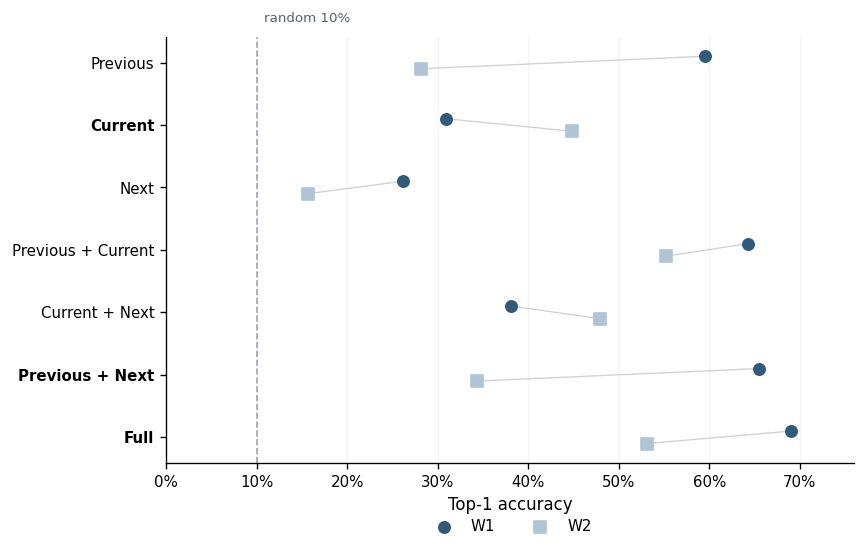

In [10]:
# Figure 1 — all context ablations

plot_data = (
    rq5_summary
    .pivot(
        index="ablation",
        columns="dataset",
        values="top1",
    )
    .reindex(
        ablation_order
    )
)

fig, ax = plt.subplots(
    figsize=(7.4, 5.0)
)

y = np.arange(
    len(ablation_order)
)

offset = 0.10

ax.scatter(
    100 * plot_data["W1"],
    y - offset,
    s=46,
    color=DARK_BLUE,
    label="W1",
    zorder=3,
)

ax.scatter(
    100 * plot_data["W2"],
    y + offset,
    s=46,
    marker="s",
    color=LIGHT_BLUE,
    label="W2",
    zorder=3,
)

for yi, ablation in enumerate(
    ablation_order
):
    ax.plot(
        [
            100 * plot_data.loc[
                ablation,
                "W1",
            ],
            100 * plot_data.loc[
                ablation,
                "W2",
            ],
        ],
        [
            yi - offset,
            yi + offset,
        ],
        color=MID_GREY,
        linewidth=0.8,
        alpha=0.5,
        zorder=1,
    )

ax.axvline(
    10,
    linestyle="--",
    linewidth=1,
    color=MID_GREY,
)

ax.text(
    10.8,
    -0.65,
    "random 10%",
    fontsize=8,
    color=DARK_GREY,
)

ax.set_yticks(
    y
)

ax.set_yticklabels(
    ablation_order
)

ax.invert_yaxis()

ax.set_xlabel(
    "Top-1 accuracy"
)

ax.set_xlim(
    0,
    76,
)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f"{x:.0f}%"
    )
)

ax.grid(
    axis="x",
    alpha=0.13,
)

ax.legend(
    frameon=False,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        -0.10,
    ),
)

for label in ax.get_yticklabels():
    if label.get_text() in {
        "Current",
        "Previous + Next",
        "Full",
    }:
        label.set_fontweight(
            "bold"
        )

fig.subplots_adjust(
    bottom=0.17
)

save_figure(
    fig,
    "RQ5_Fig1_ablation_top1",
)

plt.show()

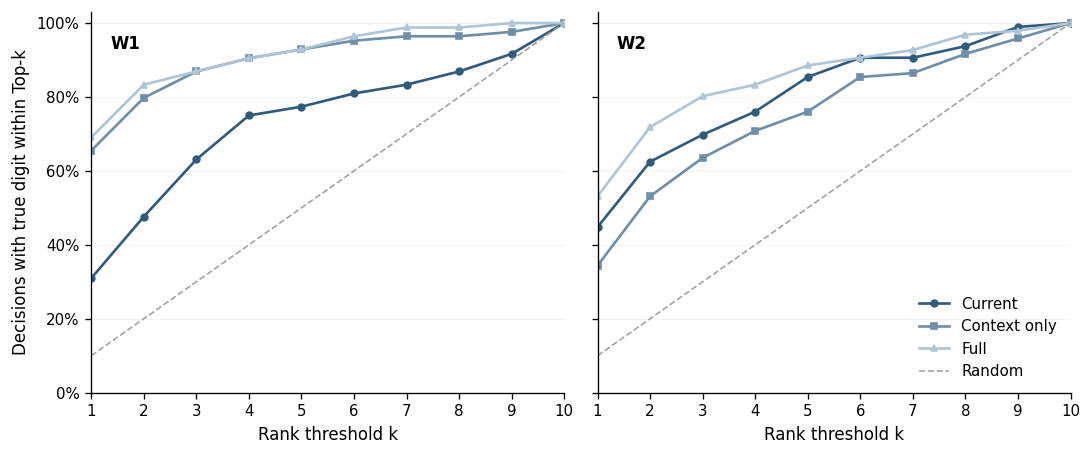

In [11]:
# Figure 2 — complete rank curves for the three key representations

def cumulative_topk(frame):
    ranks = frame[
        "true_rank"
    ].to_numpy(
        dtype=float
    )

    ks = np.arange(
        1,
        11,
    )

    values = np.array([
        np.mean(
            ranks <= k
        )
        for k in ks
    ])

    return ks, values


key_models = [
    (
        "Current",
        DARK_BLUE,
        "o",
    ),
    (
        "Previous + Next",
        MID_BLUE,
        "s",
    ),
    (
        "Full",
        LIGHT_BLUE,
        "^",
    ),
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(9.2, 3.9),
    sharey=True,
)

curve_rows = []

for ax, dataset in zip(
    axes,
    ["W1", "W2"],
):
    for (
        model,
        color,
        marker,
    ) in key_models:
        frame = rq5_predictions[
            (
                rq5_predictions[
                    "dataset"
                ]
                == dataset
            )
            &
            (
                rq5_predictions[
                    "ablation"
                ]
                == model
            )
        ]

        ks, values = cumulative_topk(
            frame
        )

        ax.plot(
            ks,
            100 * values,
            marker=marker,
            markersize=4,
            linewidth=1.6,
            color=color,
            label=(
                "Context only"
                if model
                == "Previous + Next"
                else model
            ),
        )

        for k, value in zip(
            ks,
            values,
        ):
            curve_rows.append({
                "dataset": dataset,
                "ablation": model,
                "k": int(k),
                "topk_rate": float(value),
            })

    ax.plot(
        np.arange(
            1,
            11,
        ),
        10
        * np.arange(
            1,
            11,
        ),
        linestyle="--",
        linewidth=1,
        color=MID_GREY,
        label="Random",
    )

    ax.text(
        0.04,
        0.94,
        dataset,
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold",
        va="top",
    )

    ax.set_xlim(
        1,
        10,
    )

    ax.set_ylim(
        0,
        103,
    )

    ax.set_xticks(
        np.arange(
            1,
            11,
        )
    )

    ax.set_xlabel(
        "Rank threshold k"
    )

    ax.grid(
        axis="y",
        alpha=0.13,
    )

axes[0].set_ylabel(
    "Decisions with true digit within Top-k"
)

axes[0].set_yticks(
    np.arange(
        0,
        101,
        20,
    )
)

axes[0].set_yticklabels([
    f"{v}%"
    for v in np.arange(
        0,
        101,
        20,
    )
])

axes[1].legend(
    frameon=False,
    loc="lower right",
)

fig.tight_layout()

save_figure(
    fig,
    "RQ5_Fig2_key_rank_curves",
)

pd.DataFrame(
    curve_rows
).to_csv(
    RESULT_DIR / "RQ5_cumulative_rank_curve.csv",
    index=False,
)

plt.show()

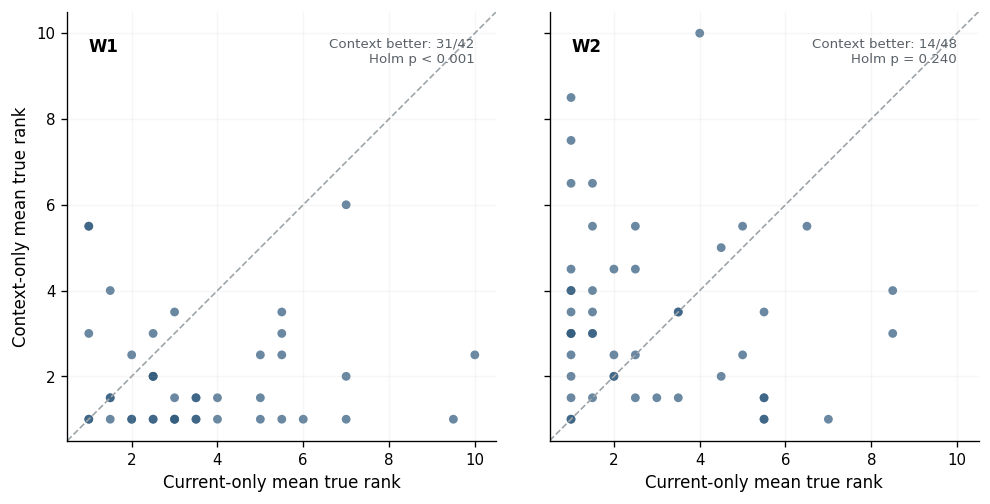

In [12]:
# Figure 3 — paired profile-level Current vs context-only rank

fig, axes = plt.subplots(
    1,
    2,
    figsize=(8.6, 4.2),
    sharex=True,
    sharey=True,
)

for ax, dataset in zip(
    axes,
    ["W1", "W2"],
):
    group = profile_wide[
        profile_wide["dataset"]
        == dataset
    ].copy()

    ax.scatter(
        group["Current"],
        group[
            "Previous + Next"
        ],
        s=28,
        color=DARK_BLUE,
        alpha=0.72,
        edgecolor="none",
    )

    ax.plot(
        [
            0.5,
            10.5,
        ],
        [
            0.5,
            10.5,
        ],
        linestyle="--",
        linewidth=1,
        color=MID_GREY,
    )

    better = int(
        (
            group[
                "Previous + Next"
            ]
            <
            group[
                "Current"
            ]
        ).sum()
    )

    test = profile_tests[
        (
            profile_tests[
                "dataset"
            ]
            == dataset
        )
        &
        (
            profile_tests[
                "comparison"
            ]
            == "Context-only vs Current"
        )
    ].iloc[0]

    p_holm = float(
        test["p_holm"]
    )

    p_text = (
        "Holm p < 0.001"
        if p_holm < 0.001
        else (
            f"Holm p = "
            f"{p_holm:.3f}"
        )
    )

    ax.text(
        0.05,
        0.94,
        dataset,
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold",
        va="top",
    )

    ax.text(
        0.95,
        0.94,
        (
            f"Context better: "
            f"{better}/{len(group)}\n"
            f"{p_text}"
        ),
        transform=ax.transAxes,
        fontsize=8,
        ha="right",
        va="top",
        color=DARK_GREY,
    )

    ax.set_xlim(
        0.5,
        10.5,
    )

    ax.set_ylim(
        0.5,
        10.5,
    )

    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    ax.grid(
        alpha=0.10,
    )

axes[0].set_ylabel(
    "Context-only mean true rank"
)

for ax in axes:
    ax.set_xlabel(
        "Current-only mean true rank"
    )

fig.tight_layout()

save_figure(
    fig,
    "RQ5_Fig3_profile_context_vs_current",
)

plt.show()

## 7. Tables and result record

In [13]:
table1 = rq5_summary.copy()

table1["Top-1"] = (
    100 * table1["top1"]
).map(
    lambda x: f"{x:.1f}%"
)

table1["Top-2"] = (
    100 * table1["top2"]
).map(
    lambda x: f"{x:.1f}%"
)

table1["Top-3"] = (
    100 * table1["top3"]
).map(
    lambda x: f"{x:.1f}%"
)

table1["Mean rank"] = (
    table1["mean_true_rank"]
).map(
    lambda x: f"{x:.2f}"
)

table1 = table1[
    [
        "dataset",
        "ablation",
        "n_decisions",
        "Top-1",
        "Top-2",
        "Top-3",
        "Mean rank",
    ]
].rename(
    columns={
        "dataset": "Dataset",
        "ablation": "Ablation",
        "n_decisions": "N decisions",
    }
)

table1.to_csv(
    RESULT_DIR / "RQ5_Table1_ablation_summary.csv",
    index=False,
)

with open(
    RESULT_DIR / "RQ5_Table1_ablation_summary.tex",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        table1.to_latex(
            index=False,
            escape=True,
        )
    )


table2 = profile_tests.copy()

table2["Model A mean rank"] = (
    table2[
        "model_a_mean_rank"
    ]
).map(
    lambda x: f"{x:.2f}"
)

table2["Model B mean rank"] = (
    table2[
        "model_b_mean_rank"
    ]
).map(
    lambda x: f"{x:.2f}"
)

table2["Median Δ rank"] = (
    table2[
        "median_rank_difference_A_minus_B"
    ]
).map(
    lambda x: f"{x:+.2f}"
)

table2["Holm p"] = (
    table2["p_holm"]
).map(
    lambda x: (
        "<0.001"
        if x < 0.001
        else f"{x:.3f}"
    )
)

table2 = table2[
    [
        "dataset",
        "comparison",
        "n_profiles",
        "Model A mean rank",
        "Model B mean rank",
        "Median Δ rank",
        "Holm p",
    ]
].rename(
    columns={
        "dataset": "Dataset",
        "comparison": "Comparison",
        "n_profiles": "N profiles",
    }
)

table2.to_csv(
    RESULT_DIR / "RQ5_Table2_profile_tests.csv",
    index=False,
)

with open(
    RESULT_DIR / "RQ5_Table2_profile_tests.tex",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        table2.to_latex(
            index=False,
            escape=True,
        )
    )

display(table1)
display(table2)

,Dataset,Ablation,N decisions,Top-1,Top-2,Top-3,Mean rank
4,W1,Previous,84,59.5%,81.0%,90.5%,1.98
0,W1,Current,84,31.0%,47.6%,63.1%,3.63
3,W1,Next,84,26.2%,39.3%,58.3%,3.62
5,W1,Previous + Current,84,64.3%,79.8%,85.7%,1.92
1,W1,Current + Next,84,38.1%,48.8%,63.1%,3.17
6,W1,Previous + Next,84,65.5%,79.8%,86.9%,1.99
2,W1,Full,84,69.0%,83.3%,86.9%,1.83
11,W2,Previous,96,28.1%,53.1%,64.6%,3.62
7,W2,Current,96,44.8%,62.5%,69.8%,2.88
10,W2,Next,96,15.6%,35.4%,52.1%,4.05


,Dataset,Comparison,N profiles,Model A mean rank,Model B mean rank,Median Δ rank,Holm p
0,W1,Context-only vs Current,42,1.99,3.63,-1.75,<0.001
1,W1,Full vs Current,42,1.83,3.63,-1.50,<0.001
2,W2,Context-only vs Current,48,3.43,2.88,+0.50,0.240
3,W2,Full vs Current,48,2.45,2.88,+0.00,0.240


In [14]:
w1 = (
    rq5_summary[
        rq5_summary["dataset"]
        == "W1"
    ]
    .set_index(
        "ablation"
    )
)

w2 = (
    rq5_summary[
        rq5_summary["dataset"]
        == "W2"
    ]
    .set_index(
        "ablation"
    )
)

rq5_conclusion = {
    "research_question": (
        "Is discriminative information local to the current movement, "
        "or can neighbouring movements alone predict the true-gate label?"
    ),
    "analysis_type": (
        "Controlled confirmatory context ablation"
    ),
    "method": (
        "13 pre-specified target-channel acoustic features for Previous, "
        "Current and Next movements; leave-one-profile-out logistic regression."
    ),
    "W1": {
        "current_top1": float(
            w1.loc[
                "Current",
                "top1",
            ]
        ),
        "context_only_top1": float(
            w1.loc[
                "Previous + Next",
                "top1",
            ]
        ),
        "full_top1": float(
            w1.loc[
                "Full",
                "top1",
            ]
        ),
        "current_mean_rank": float(
            w1.loc[
                "Current",
                "mean_true_rank",
            ]
        ),
        "context_only_mean_rank": float(
            w1.loc[
                "Previous + Next",
                "mean_true_rank",
            ]
        ),
    },
    "W2": {
        "current_top1": float(
            w2.loc[
                "Current",
                "top1",
            ]
        ),
        "context_only_top1": float(
            w2.loc[
                "Previous + Next",
                "top1",
            ]
        ),
        "full_top1": float(
            w2.loc[
                "Full",
                "top1",
            ]
        ),
        "current_mean_rank": float(
            w2.loc[
                "Current",
                "mean_true_rank",
            ]
        ),
        "context_only_mean_rank": float(
            w2.loc[
                "Previous + Next",
                "mean_true_rank",
            ]
        ),
    },
    "profile_level_tests": (
        profile_tests.to_dict(
            orient="records"
        )
    ),
    "interpretation": (
        "Context dependence is strongly wheel-specific. For W1, the two neighbouring "
        "movements alone outperform the Current movement by a large margin and nearly "
        "match Full-context performance, providing direct evidence that the label can "
        "be inferred from contextual transition structure rather than the current "
        "true-gate movement alone. For W2, Current remains the strongest single cue; "
        "context-only performance is weaker and is not significantly different from "
        "Current at profile level after Holm correction. Adding context to Current "
        "still raises the descriptive Top-1 result."
    ),
    "limitation": (
        "The recovered historical context model was not available, so this is a "
        "controlled reanalysis using the fixed 13-feature interpretable representation. "
        "These data use a single true digit per wheel. RQ4 also showed stable "
        "transition-specific acoustic fingerprints, so context performance may reflect "
        "password-specific transition identity rather than transferable gate physics."
    ),
    "next_step": (
        "RQ6 tests the same context mechanism on different passwords to distinguish "
        "transferable mechanical structure from password-dependent shortcut learning."
    ),
}

with open(
    RESULT_DIR / "RQ5_conclusion.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        rq5_conclusion,
        f,
        indent=2,
    )

run_info = {
    "notebook": "05_RQ5_Prev_Current_Next.ipynb",
    "data_sources": [
        "dataset/raw/historical_data/digit_W1_data.zip",
        "dataset/raw/historical_data/digit_W2_data.zip",
    ],
    "feature_cache": (
        "results/feature_cache/RQ5_context_interpretable_v1.npz"
    ),
    "feature_count_per_movement": 13,
    "ablations": ablation_order,
    "validation": "leave-one-profile-out",
    "classifier": {
        "type": "LogisticRegression",
        "C": 1.0,
        "solver": "liblinear",
        "class_weight": "balanced",
        "random_state": 0,
    },
    "primary_comparison": (
        "Previous + Next versus Current"
    ),
    "statistics": (
        "Profile-level two-sided paired Wilcoxon; Holm correction across "
        "W1/W2 × {Context-only vs Current, Full vs Current}."
    ),
}

with open(
    RESULT_DIR / "RQ5_run_info.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        run_info,
        f,
        indent=2,
    )

print(
    json.dumps(
        rq5_conclusion,
        indent=2,
    )
)

print("\nSaved outputs:")
for path in sorted(
    RESULT_DIR.glob("RQ5_*")
):
    print(
        " -",
        path.name,
    )

{
  "research_question": "Is discriminative information local to the current movement, or can neighbouring movements alone predict the true-gate label?",
  "analysis_type": "Controlled confirmatory context ablation",
  "method": "13 pre-specified target-channel acoustic features for Previous, Current and Next movements; leave-one-profile-out logistic regression.",
  "W1": {
    "current_top1": 0.30952380952380953,
    "context_only_top1": 0.6547619047619048,
    "full_top1": 0.6904761904761905,
    "current_mean_rank": 3.630952380952381,
    "context_only_mean_rank": 1.9880952380952381
  },
  "W2": {
    "current_top1": 0.4479166666666667,
    "context_only_top1": 0.34375,
    "full_top1": 0.53125,
    "current_mean_rank": 2.875,
    "context_only_mean_rank": 3.4270833333333335
  },
  "profile_level_tests": [
    {
      "dataset": "W1",
      "comparison": "Context-only vs Current",
      "n_profiles": 42,
      "model_a_mean_rank": 1.9880952380952381,
      "model_b_mean_rank": 3.630